# Qwen3-VL MoE — Expert Routing Analysis (Image vs Text Tokens)

**Goal:** Extract the router logits from every MoE layer in `Qwen3-VL-30B-A3B-Instruct` and compare how the model routes **image (visual) tokens** versus **text tokens** to its 128 experts.

**Setup:** Google Colab → Runtime → Change runtime type → **NVIDIA RTX PRO 6000 Blackwell Server Edition GPU (102GB VRAM)**

| Property | Value |
|---|---|
| Model | `Qwen/Qwen3-VL-30B-A3B-Instruct` |
| Quantisation | 4-bit NF4 via bitsandbytes (~8–10 GB VRAM) |
| Experts / layer | 128 routed, **top-4** activated per token |
| Router class | `Qwen3VLMoeTextTopKRouter` (softmax → top-k) |
| Vision token marker | `<\|image_pad\|>` in `input_ids` |

---
## Cell 1 — Install dependencies

In [1]:
!pip install -q --upgrade \
    transformers \
    accelerate \
    "bitsandbytes>=0.46.1" \
    "Pillow<12.0.0" \
    matplotlib \
    requests

---
## Cell 2 — Configuration & GPU check

In [2]:
import torch, gc, os

MODEL_ID = "Qwen/Qwen3-VL-30B-A3B-Instruct"

#PROMPT = "Describe this image in detail."
PROMPT = "What is the main subject of this image?"

# --- Image source (pick ONE) -----------------------------------------
# Option A: public URL (works out of the box, no upload needed)
IMAGE_SOURCE = "https://raw.githubusercontent.com/QwenLM/Qwen-VL/master/assets/demo.jpeg"
#IMAGE_SOURCE = "https://images.unsplash.com/photo-1611080626919-7cf5a9dbab5b?w=400"


# Option B: upload your own image — uncomment the two lines below,
#           comment out Option A above, and run Cell 3.
# IMAGE_SOURCE = None  # will be set after upload in Cell 3
# ---------------------------------------------------------------------

assert torch.cuda.is_available(), "No GPU detected — change runtime to T4!"
gpu = torch.cuda.get_device_properties(0)
print(f"GPU  : {gpu.name}")
print(f"VRAM : {gpu.total_memory / 1e9:.1f} GB")
print(f"Model: {MODEL_ID}")
print(f"Quant: 4-bit NF4 (bitsandbytes)")

GPU  : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM : 102.0 GB
Model: Qwen/Qwen3-VL-30B-A3B-Instruct
Quant: 4-bit NF4 (bitsandbytes)


---
## Cell 3 — (Optional) Upload your own image

Skip this cell if you're using the default URL above.

In [3]:
# Uncomment and run ONLY if you set IMAGE_SOURCE = None in Cell 2

# from google.colab import files
# uploaded = files.upload()
# IMAGE_SOURCE = list(uploaded.keys())[0]
# print(f"Using: {IMAGE_SOURCE}")

---
## Cell 4 — Load model in 4-bit quantisation

This takes ~3–5 min on first run (downloads ~17 GB of sharded safetensors).

In [4]:
import os
os.environ["BNB_CUDA_VERSION"] = "121"  # Force bitsandbytes to use CUDA 12.1 backend

from transformers import (
    Qwen3VLMoeForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,      # extra compression
    llm_int8_enable_fp32_cpu_offload=True # Allows offloading overflow to CPU
)

print(f"Loading {MODEL_ID} (4-bit) …")
model = Qwen3VLMoeForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    offload_folder="offload"
)
model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)

param_b = sum(p.numel() for p in model.parameters()) / 1e9
vram_used = torch.cuda.memory_allocated() / 1e9
print(f"Loaded {param_b:.1f}B params — VRAM used: {vram_used:.1f} GB")

Loading Qwen/Qwen3-VL-30B-A3B-Instruct (4-bit) …


This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=



Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/882 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded 30.4B params — VRAM used: 60.0 GB


---
## Cell 5 — Register forward hooks on every MoE router

Each MoE decoder layer contains a `Qwen3VLMoeTextSparseMoeBlock` whose
`.gate` is a `Qwen3VLMoeTextTopKRouter`.  Its `forward()` returns
`(router_logits, router_scores, router_indices)` where `router_logits`
has shape `(seq_len, 128)` — the **post-softmax** probability that each
token is routed to each of the 128 experts.



In [5]:
from collections import defaultdict

# TEMPORARY DEBUGGING STEP: Inspect model structure
print("--- Debugging Model Structure for MoE Layers ---")
print(f"Type of model: {type(model)}")
print("Attributes of model:")
for attr in sorted(dir(model)):
    print(f"- {attr}")
print("\n")

print(f"Type of model.model: {type(model.model)}")
print("Attributes of model.model (full list):")
for attr in sorted(dir(model.model)):
    print(f"- {attr}")
print("\n")

# New: check text_model if it exists
if hasattr(model.model, 'text_model'):
    print(f"Type of model.model.text_model: {type(model.model.text_model)}")
    print("Attributes of model.model.text_model (full list):")
    for attr in sorted(dir(model.model.text_model)):
        print(f"- {attr}")
    print("\n")
else:
    print("model.model does not have 'text_model' attribute.\n")

print("model.model._modules keys:")
if hasattr(model.model, '_modules'):
    for name, module in model.model._modules.items():
        print(f"- {name}: {type(module)}")
else:
    print("model.model does not have _modules attribute.")
print("\n")


class RouterLogitsCapture:
    """Captures post-softmax router probabilities from every MoE gate."""

    def __init__(self, model):
        self.data: dict[int, list[torch.Tensor]] = defaultdict(list)
        self._hooks = []
        self._moe_layers = []          # track which layer indices are MoE

        target_layers = None

        # --- New, more comprehensive path search ---

        # 1. Check directly on the main 'model' object if it contains 'h' or 'layers'
        if hasattr(model, 'h'):
            target_layers = model.h
            print("Info: Using model.h for MoE layer access.")
        elif hasattr(model, 'layers'):
            target_layers = model.layers
            print("Info: Using model.layers for MoE layer access.")

        # 2. Check under model.model (as in previous attempts)
        elif hasattr(model.model, 'h'):
            target_layers = model.model.h
            print("Info: Using model.model.h for MoE layer access.")
        elif hasattr(model.model, 'layers'):
            target_layers = model.model.layers
            print("Info: Using model.model.layers for MoE layer access.")

        # 3. Check under model.decoder (as identified in some previous debugging output hints)
        elif hasattr(model, 'decoder') and hasattr(model.decoder, 'h'):
            target_layers = model.decoder.h
            print("Info: Using model.decoder.h for MoE layer access.")
        elif hasattr(model, 'decoder') and hasattr(model.decoder, 'layers'):
            target_layers = model.decoder.layers
            print("Info: Using model.decoder.layers for MoE layer access.")

        # 4. Check within model.model.text_model (for multimodal models like Qwen-VL)
        elif hasattr(model.model, 'text_model'):
            text_sub_model = model.model.text_model
            if hasattr(text_sub_model, 'model') and hasattr(text_sub_model.model, 'h'):
                target_layers = text_sub_model.model.h
                print("Info: Using model.model.text_model.model.h for MoE layer access.")
            elif hasattr(text_sub_model, 'h'):
                target_layers = text_sub_model.h
                print("Info: Using model.model.text_model.h for MoE layer access.")
            elif hasattr(text_sub_model, 'layers'):
                target_layers = text_sub_model.layers
                print("Info: Using model.model.text_model.layers for MoE layer access.")

        # 5. Check within model.model.language_model (identified in current debug output)
        elif hasattr(model.model, 'language_model'):
            lang_sub_model = model.model.language_model
            if hasattr(lang_sub_model, 'h'):
                target_layers = lang_sub_model.h
                print("Info: Using model.model.language_model.h for MoE layer access.")
            elif hasattr(lang_sub_model, 'layers'):
                target_layers = lang_sub_model.layers
                print("Info: Using model.model.language_model.layers for MoE layer access.")


        if target_layers is None:
            raise AttributeError(
                "Could not find 'layers' or 'h' attribute in any expected path within model, model.model, model.decoder, "
                "or model.model.text_model. Please inspect the model structure to find the correct attribute for decoder layers."
            )

        for idx, layer in enumerate(target_layers):
            if hasattr(layer, "mlp") and hasattr(layer.mlp, "gate"):
                h = layer.mlp.gate.register_forward_hook(self._make_hook(idx))
                self._hooks.append(h)
                self._moe_layers.append(idx)

        print(f"Hooks on {len(self._moe_layers)} MoE layers "
              f"(of {len(target_layers)} total decoder layers)")

    def _make_hook(self, layer_idx):
        def fn(_module, _input, output):
            # output[0] = router_logits  (seq_len, num_experts) — post-softmax
            self.data[layer_idx].append(output[0].detach().float().cpu())
        return fn

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

capture = RouterLogitsCapture(model)

--- Debugging Model Structure for MoE Layers ---
Type of model: <class 'transformers.models.qwen3_vl_moe.modeling_qwen3_vl_moe.Qwen3VLMoeForConditionalGeneration'>
Attributes of model:
- T_destination
- __annotations__
- __call__
- __class__
- __delattr__
- __dict__
- __dir__
- __doc__
- __eq__
- __format__
- __ge__
- __getattr__
- __getattribute__
- __getstate__
- __gt__
- __hash__
- __init__
- __init_subclass__
- __le__
- __lt__
- __module__
- __ne__
- __new__
- __reduce__
- __reduce_ex__
- __repr__
- __setattr__
- __setstate__
- __sizeof__
- __str__
- __subclasshook__
- __weakref__
- _adjust_bias
- _adjust_missing_and_unexpected_keys
- _apply
- _assisted_decoding
- _auto_class
- _backward_compatibility_gradient_checkpointing
- _backward_hooks
- _backward_pre_hooks
- _beam_search
- _beam_search_has_unfinished_sequences
- _buffers
- _call_impl
- _can_compile_fullgraph
- _can_record_outputs
- _can_set_attn_implementation
- _can_set_experts_implementation
- _can_set_experts_implementati

---
## Cell 6 — Build multimodal input & identify image vs text positions

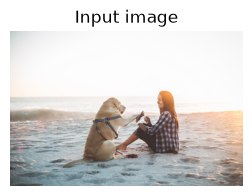

Sequence length : 2771
  Image tokens  : 2754  (99.4%)
  Text tokens   : 17  (0.6%)


In [6]:
import requests, io
from PIL import Image
import matplotlib.pyplot as plt

# Load image from URL or local path
if IMAGE_SOURCE.startswith("http"):
    # Add a User-Agent header to avoid 403 Forbidden errors from sites like Wikimedia
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    response = requests.get(IMAGE_SOURCE, headers=headers)
    image = Image.open(io.BytesIO(response.content)).convert("RGB")
else:
    image = Image.open(IMAGE_SOURCE).convert("RGB")

plt.figure(figsize=(3, 3))
plt.imshow(image); plt.axis("off"); plt.title("Input image"); plt.show()

# Build chat-template input
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text":  PROMPT},
    ],
}]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
)

device = next(model.parameters()).device
inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v
          for k, v in inputs.items()}

# --- Identify which positions are image vs text ---
input_ids = inputs["input_ids"][0].cpu()
seq_len   = input_ids.shape[0]

# <|image_pad|> carries the bulk of vision content;
# <|vision_start|> and <|vision_end|> are boundary markers.
pad_id   = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
start_id = processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
end_id   = processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")

unk = processor.tokenizer.unk_token_id
is_image = torch.zeros(seq_len, dtype=torch.bool)
for tid in (pad_id, start_id, end_id):
    if tid is not None and tid != unk:
        is_image |= (input_ids == tid)
is_text = ~is_image

n_img = is_image.sum().item()
n_txt = is_text.sum().item()
print(f"Sequence length : {seq_len}")
print(f"  Image tokens  : {n_img}  ({100*n_img/seq_len:.1f}%)")
print(f"  Text tokens   : {n_txt}  ({100*n_txt/seq_len:.1f}%)")

In [7]:
# with open('downloaded_content.tmp', 'rb') as f:
#     content = f.read()
#     print(content[:500]) # Print first 500 bytes to avoid overwhelming output
#     # Optionally, try to decode as text if it seems like text
#     try:
#         print(content.decode('utf-8'))
#     except UnicodeDecodeError:
#         print("\n--- Content could not be decoded as UTF-8 (might be binary) ---")


In [8]:
# import requests
# from PIL import Image
# import io

# print(f"Checking image source: {IMAGE_SOURCE}")

# # Make a request to the image URL
# try:
#     response = requests.get(IMAGE_SOURCE)
#     response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

#     print(f"HTTP Status Code: {response.status_code}")
#     print(f"Content Type: {response.headers.get('Content-Type')}")

#     # Always save the raw content for inspection
#     with open("downloaded_content.tmp", "wb") as f:
#         f.write(response.content)
#     print("Content saved to 'downloaded_content.tmp' for inspection.")

#     # Try to open the image content
#     try:
#         image = Image.open(io.BytesIO(response.content))
#         image.verify() # Verify if it's an image
#         print("Image successfully opened and verified by PIL!")
#         print(f"Image format: {image.format}, size: {image.size}, mode: {image.mode}")
#     except Exception as e:
#         print(f"Error opening or verifying image with PIL: {e}")
#         print("The content downloaded does not appear to be a valid image to PIL.")

# except requests.exceptions.RequestException as e:
#     print(f"Error fetching image from URL: {e}")
#     print("Please check if the IMAGE_SOURCE URL is correct and accessible.")

The above cell should tell us if the `IMAGE_SOURCE` URL is valid and returns an image. If it indicates an issue, you may need to update the `IMAGE_SOURCE` variable in Cell 2 with a new, working image URL.

---
## Cell 7 — Forward pass (extracts all router logits via hooks)

In [9]:
print("Running forward pass …")
with torch.no_grad():
    outputs = model(**inputs)
print("Forward pass complete.")

# Detach hooks so they don't fire during later generate() calls
capture.remove()

# Free GPU memory we no longer need
del outputs
gc.collect(); torch.cuda.empty_cache()
print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Running forward pass …
Forward pass complete.
VRAM after cleanup: 60.1 GB


In [10]:
# Convert log-probabilities to probabilities
import torch

# Check if already converted
sample = torch.cat(capture.data[0], dim=0)
if sample.min() < 0:
    # Convert log-probabilities to probabilities
    for layer_idx in capture.data:
        capture.data[layer_idx] = [torch.exp(t) for t in capture.data[layer_idx]]
    print("✓ Converted log-probabilities to probabilities")
else:
    print("✓ Already converted")

✓ Converted log-probabilities to probabilities


In [11]:
# Verify probabilities are valid
layer_idx = 0
probs = torch.cat(capture.data[layer_idx], dim=0)

print(f"Min value: {probs.min():.6f}  (should be ~0)")
print(f"Max value: {probs.max():.6f}  (should be ~0.02)")
print(f"Sum per token: {probs.sum(dim=1).mean():.6f}  (should be ~1.0)")


Min value: 0.000123  (should be ~0)
Max value: 0.164045  (should be ~0.02)
Sum per token: 0.959404  (should be ~1.0)


---
## Cell 8 — Compute per-layer expert distributions for image vs text

In [12]:
import numpy as np

layers      = sorted(capture.data.keys())
num_experts = None
img_rows, txt_rows = [], []

for li in layers:
    probs = torch.cat(capture.data[li], dim=0)        # (seq_len, E)
    if num_experts is None:
        num_experts = probs.shape[-1]

    img_mean = probs[is_image].mean(0).numpy() if is_image.any() else np.zeros(num_experts)
    txt_mean = probs[is_text].mean(0).numpy()  if is_text.any()  else np.zeros(num_experts)
    img_rows.append(img_mean)
    txt_rows.append(txt_mean)

img_dists = np.stack(img_rows)   # shape (num_moe_layers, num_experts)
txt_dists = np.stack(txt_rows)

print(f"{len(layers)} MoE layers captured, {num_experts} experts each")

48 MoE layers captured, 128 experts each


---
## Cell 9 — Per-layer summary table

For every MoE layer we show:
- **Top-1 expert** (highest mean routing prob) for image and text tokens
- **Shannon entropy** H (higher = more uniform routing, lower = concentrated)

In [13]:
def entropy(p):
    """Shannon entropy in bits."""
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

header = (f"{'Layer':>6}  {'Top-1 IMG':>18}  {'Top-1 TXT':>18}"
          f"  {'H(img)':>8}  {'H(txt)':>8}  {'Same?':>5}")
print(header)
print("─" * len(header))

same_count = 0
for i, li in enumerate(layers):
    t1_i = np.argmax(img_dists[i])
    t1_t = np.argmax(txt_dists[i])
    same = t1_i == t1_t
    same_count += same
    print(f"  {li:>4}   Expert {t1_i:>2} ({img_dists[i][t1_i]:.4f})"
          f"   Expert {t1_t:>2} ({txt_dists[i][t1_t]:.4f})"
          f"   {entropy(img_dists[i]):>7.3f}   {entropy(txt_dists[i]):>7.3f}"
          f"  {'  ✓' if same else '  ✗'}")

pct_same = 100 * same_count / len(layers)
print(f"\nTop-1 expert matches in {same_count}/{len(layers)} layers ({pct_same:.0f}%)")
if pct_same < 50:
    print("→ Image and text tokens are routed to DIFFERENT preferred experts in most layers.")
else:
    print("→ Image and text tokens share the SAME preferred expert in most layers.")

 Layer           Top-1 IMG           Top-1 TXT    H(img)    H(txt)  Same?
─────────────────────────────────────────────────────────────────────────
     0   Expert 74 (0.0091)   Expert 16 (0.0320)     6.765     7.061    ✗
     1   Expert 64 (0.0096)   Expert 68 (0.0303)     6.698     6.944    ✗
     2   Expert 98 (0.0100)   Expert 92 (0.0645)     6.788     7.009    ✗
     3   Expert 127 (0.0115)   Expert 82 (0.0627)     6.902     6.976    ✗
     4   Expert 127 (0.0121)   Expert 16 (0.0373)     6.930     6.843    ✗
     5   Expert 25 (0.0109)   Expert 13 (0.0463)     6.853     7.108    ✗
     6   Expert 60 (0.0116)   Expert  8 (0.0334)     6.892     6.908    ✗
     7   Expert 38 (0.0129)   Expert 106 (0.0386)     6.842     6.884    ✗
     8   Expert 73 (0.0110)   Expert 96 (0.0369)     6.805     6.783    ✗
     9   Expert 74 (0.0113)   Expert 10 (0.0481)     6.818     6.649    ✗
    10   Expert  7 (0.0110)   Expert 38 (0.0406)     6.782     6.422    ✗
    11   Expert 120 (0.0119)   Expe

---
## Cell 10 — Global top-5 experts & KL divergence

In [14]:
avg_img = img_dists.mean(axis=0)   # (num_experts,)
avg_txt = txt_dists.mean(axis=0)

print("═" * 60)
print("GLOBAL EXPERT RANKING  (averaged across all MoE layers)")
print("═" * 60)

for label, dist in [("IMAGE tokens", avg_img), ("TEXT tokens", avg_txt)]:
    top5 = np.argsort(dist)[::-1][:5]
    print(f"\n  {label}:")
    for rank, eid in enumerate(top5, 1):
        bar = "█" * int(dist[eid] * 300)   # visual bar
        print(f"    #{rank}  Expert {eid:>2}   prob {dist[eid]:.5f}  {bar}")

# Overlap analysis
img_top10 = set(np.argsort(avg_img)[::-1][:10])
txt_top10 = set(np.argsort(avg_txt)[::-1][:10])
overlap   = img_top10 & txt_top10
img_only  = img_top10 - txt_top10
txt_only  = txt_top10 - img_top10

print(f"\n  Top-10 overlap : {len(overlap)} experts  {sorted(overlap)}")
print(f"  Image-only     : {len(img_only)} experts  {sorted(img_only)}")
print(f"  Text-only      : {len(txt_only)} experts  {sorted(txt_only)}")

# KL divergence
def kl_div(p, q, eps=1e-10):
    p = np.clip(p, eps, None); p /= p.sum()
    q = np.clip(q, eps, None); q /= q.sum()
    return float(np.sum(p * np.log(p / q)))

kl_fwd = kl_div(avg_img, avg_txt)
kl_rev = kl_div(avg_txt, avg_img)
js_div = 0.5 * (kl_fwd + kl_rev)

print(f"\n  KL(image ‖ text) = {kl_fwd:.4f}")
print(f"  KL(text ‖ image) = {kl_rev:.4f}")
print(f"  JS divergence    = {js_div:.4f}")
print(f"  (higher → image and text use more different expert subsets)")

════════════════════════════════════════════════════════════
GLOBAL EXPERT RANKING  (averaged across all MoE layers)
════════════════════════════════════════════════════════════

  IMAGE tokens:
    #1  Expert 69   prob 0.00975  ██
    #2  Expert 59   prob 0.00925  ██
    #3  Expert 45   prob 0.00922  ██
    #4  Expert 22   prob 0.00869  ██
    #5  Expert 79   prob 0.00854  ██

  TEXT tokens:
    #1  Expert 96   prob 0.01268  ███
    #2  Expert 78   prob 0.01188  ███
    #3  Expert 26   prob 0.01186  ███
    #4  Expert 103   prob 0.01158  ███
    #5  Expert 10   prob 0.01136  ███

  Top-10 overlap : 0 experts  []
  Image-only     : 10 experts  [np.int64(2), np.int64(22), np.int64(45), np.int64(51), np.int64(59), np.int64(69), np.int64(79), np.int64(91), np.int64(107), np.int64(119)]
  Text-only      : 10 experts  [np.int64(8), np.int64(10), np.int64(16), np.int64(26), np.int64(56), np.int64(73), np.int64(78), np.int64(96), np.int64(103), np.int64(115)]

  KL(image ‖ text) = 0.0181
  KL

---
## Cell 11 — Visualisation: Routing heatmaps + global bar chart

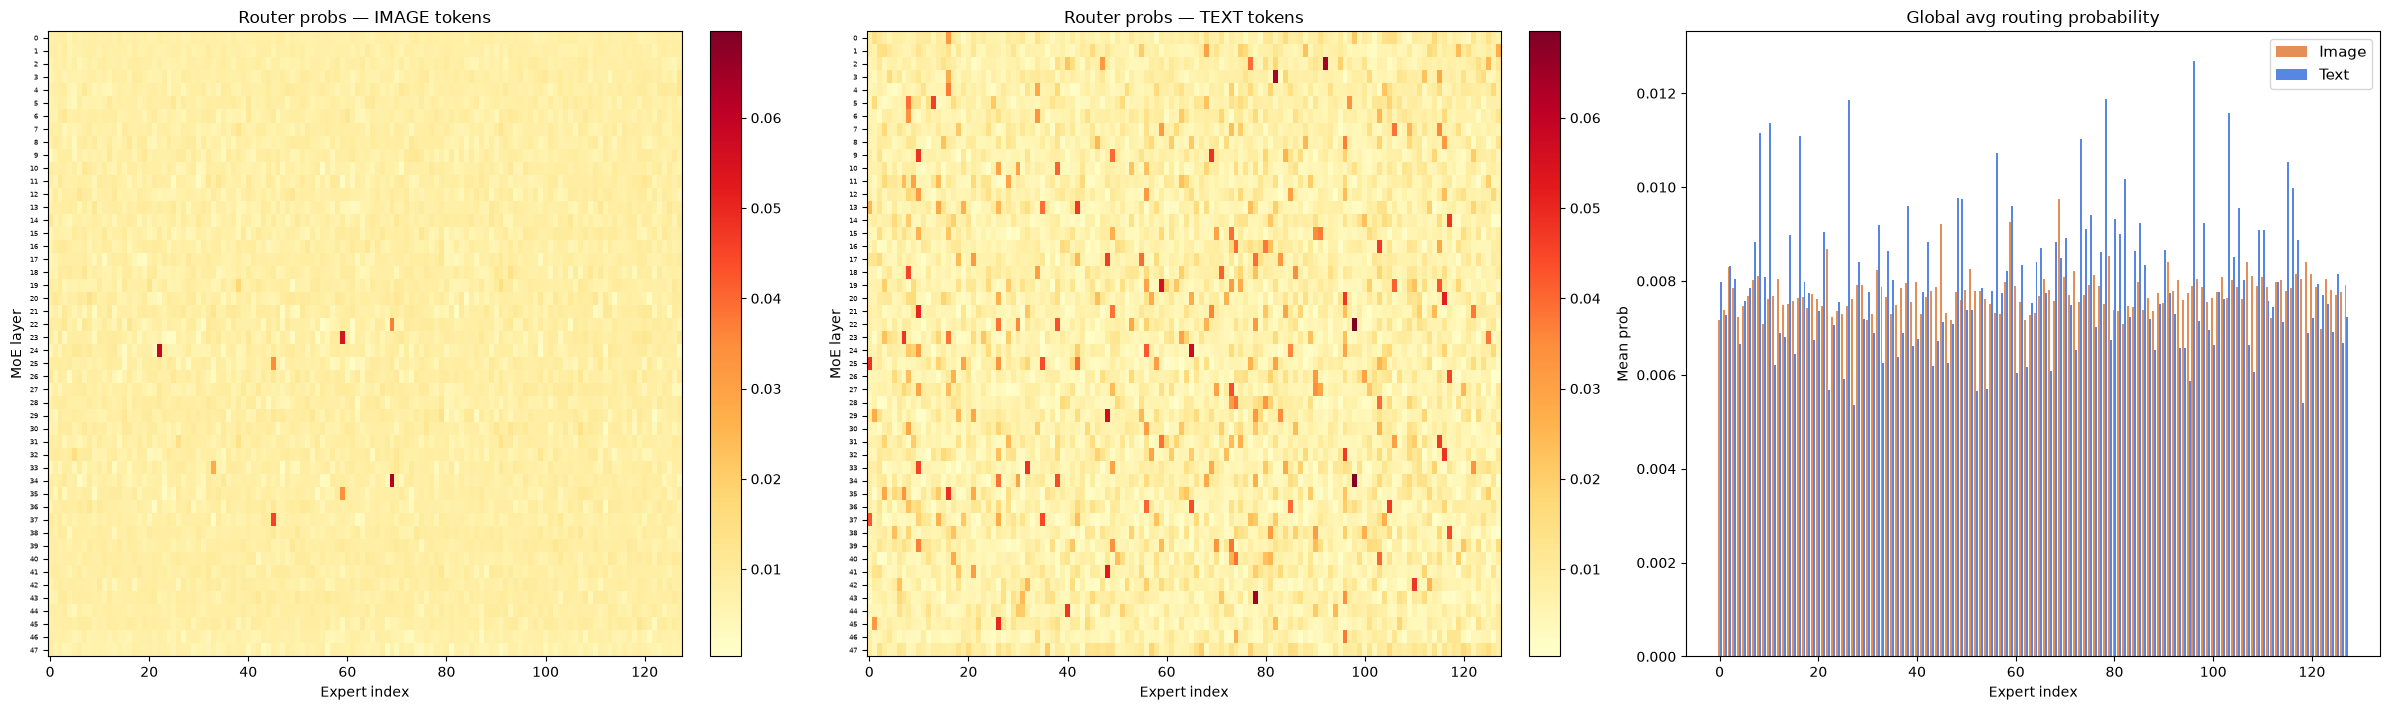

Saved → routing_heatmaps.png


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, max(6, len(layers) * 0.15)))

# Shared color scale for the two heatmaps
vmin = min(img_dists.min(), txt_dists.min())
vmax = max(img_dists.max(), txt_dists.max())

for ax, data, title in [
    (axes[0], img_dists, "Router probs — IMAGE tokens"),
    (axes[1], txt_dists, "Router probs — TEXT tokens"),
]:
    im = ax.imshow(data, aspect="auto", cmap="YlOrRd",
                   interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Expert index")
    ax.set_ylabel("MoE layer")
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layers, fontsize=5)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Difference heatmap would also be useful but let's do the bar chart
ax = axes[2]
x = np.arange(num_experts)
w = 0.4
ax.bar(x - w/2, avg_img, w, label="Image", alpha=0.85, color="#e07b39")
ax.bar(x + w/2, avg_txt, w, label="Text",  alpha=0.85, color="#3971e0")
ax.set_title("Global avg routing probability", fontsize=12)
ax.set_xlabel("Expert index")
ax.set_ylabel("Mean prob")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("routing_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → routing_heatmaps.png")

---
## Cell 12 — Visualisation: Routing entropy per layer

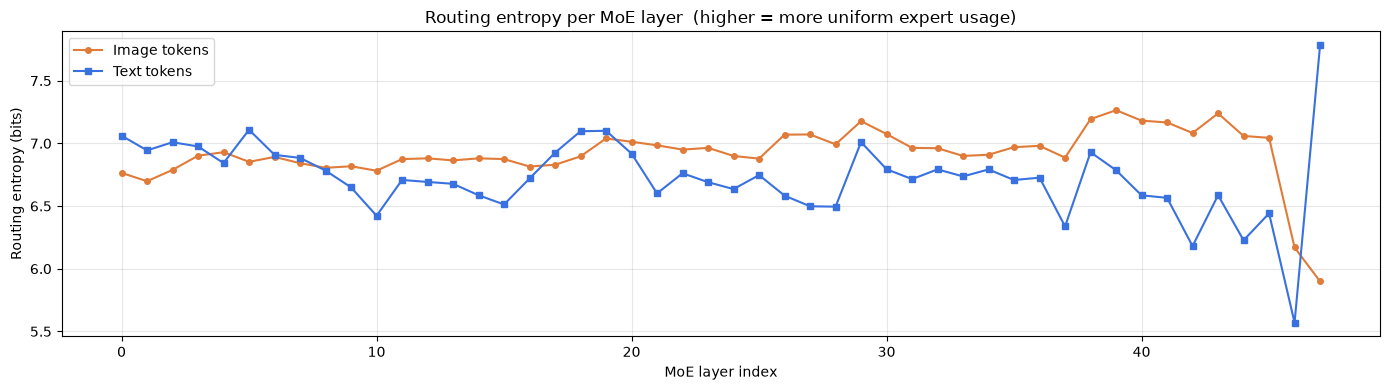

Saved → routing_entropy.png


In [16]:
img_ent = [entropy(img_dists[i]) for i in range(len(layers))]
txt_ent = [entropy(txt_dists[i]) for i in range(len(layers))]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(layers, img_ent, "o-", label="Image tokens", color="#e07b39", markersize=4)
ax.plot(layers, txt_ent, "s-", label="Text tokens",  color="#3971e0", markersize=4)
ax.set_xlabel("MoE layer index")
ax.set_ylabel("Routing entropy (bits)")
ax.set_title("Routing entropy per MoE layer  (higher = more uniform expert usage)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("routing_entropy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → routing_entropy.png")

---
## Cell 13 — Visualisation: Top-4 activated experts per position (token-level view)

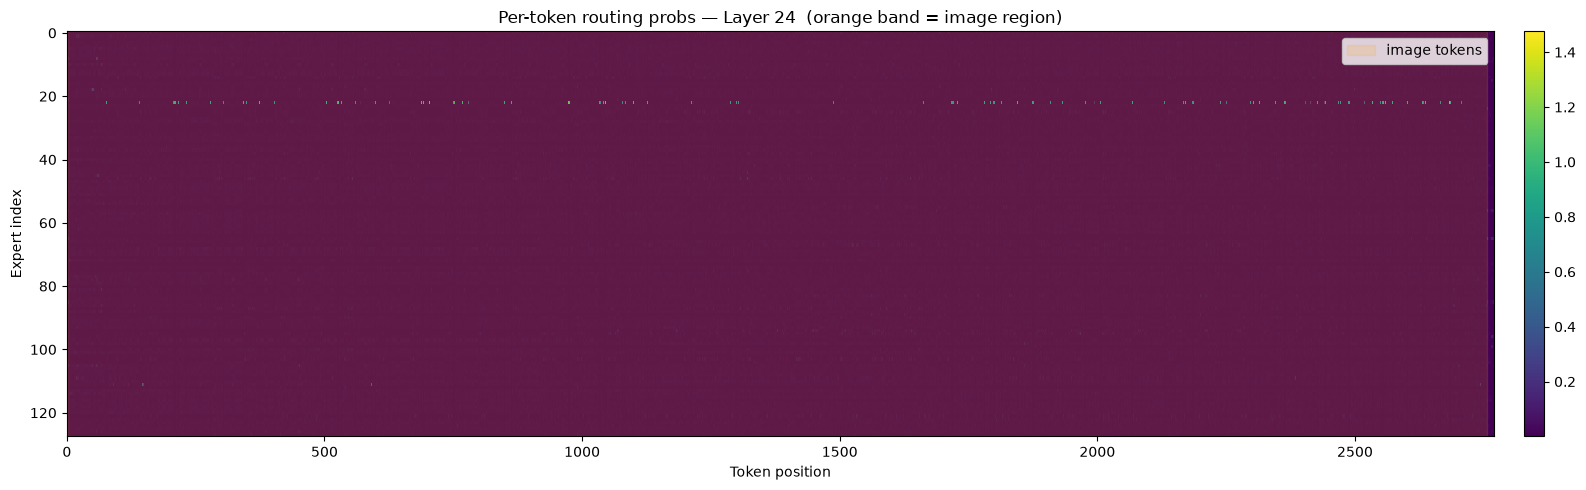

Saved → routing_token_level.png  (layer 24)


In [17]:
# Pick a representative middle MoE layer for a token-level deep dive
mid_idx   = len(layers) // 2
mid_layer = layers[mid_idx]
probs     = torch.cat(capture.data[mid_layer], dim=0).numpy()  # (seq_len, 128)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(probs.T, aspect="auto", cmap="viridis", interpolation="nearest")
ax.set_xlabel("Token position")
ax.set_ylabel("Expert index")
ax.set_title(f"Per-token routing probs — Layer {mid_layer}  "
             f"(orange band = image region)")

# Shade the image-token region
img_positions = is_image.nonzero(as_tuple=True)[0]
if len(img_positions) > 0:
    ax.axvspan(img_positions[0].item(), img_positions[-1].item(),
               alpha=0.15, color="orange", label="image tokens")
    ax.legend(loc="upper right")

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
plt.tight_layout()
plt.savefig("routing_token_level.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → routing_token_level.png  (layer {mid_layer})")

---
## Cell 14 — Research-ready summary for copy/paste

In [18]:
print("")
print("═" * 70)
print("  RESEARCH SUMMARY — Qwen3-VL-30B-A3B Expert Routing Analysis")
print("═" * 70)
print(f"")
print(f"  Model           : {MODEL_ID}")
print(f"  Quantisation    : 4-bit NF4 (bitsandbytes)")
print(f"  MoE layers      : {len(layers)}")
print(f"  Experts / layer : {num_experts} (top-4 activated)")
print(f"  Sequence length : {seq_len} tokens")
print(f"  Image tokens    : {n_img}  ({100*n_img/seq_len:.1f}%)")
print(f"  Text tokens     : {n_txt}  ({100*n_txt/seq_len:.1f}%)")
print(f"")
print(f"  --- Divergence Metrics ---")
print(f"  KL(image ‖ text)  : {kl_fwd:.4f}")
print(f"  KL(text ‖ image)  : {kl_rev:.4f}")
print(f"  JS divergence     : {js_div:.4f}")
print(f"")
print(f"  --- Expert Overlap (top-10) ---")
print(f"  Shared            : {len(overlap)}/10  {sorted(overlap)}")
print(f"  Image-specialised : {len(img_only)}     {sorted(img_only)}")
print(f"  Text-specialised  : {len(txt_only)}     {sorted(txt_only)}")
print(f"")
print(f"  --- Entropy (bits, averaged across layers) ---")
print(f"  Image tokens      : {np.mean(img_ent):.3f}")
print(f"  Text tokens       : {np.mean(txt_ent):.3f}")
print(f"")

if np.mean(img_ent) < np.mean(txt_ent):
    print("  Finding: Image tokens exhibit LOWER entropy (more concentrated")
    print("  routing), suggesting the model activates a narrower, more")
    print("  specialised set of experts for visual processing.")
else:
    print("  Finding: Text tokens exhibit LOWER entropy (more concentrated")
    print("  routing), suggesting text processing relies on a narrower")
    print("  set of preferred experts.")

pct_diff = 100 * len(img_only) / 10
print(f"")
print(f"  {pct_diff:.0f}% of the top-10 image experts are NOT in the top-10")
print(f"  text experts, indicating modality-specific expert specialisation.")
print(f"")
print("═" * 70)
print("  Plots saved: routing_heatmaps.png, routing_entropy.png,")
print("               routing_token_level.png")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
  RESEARCH SUMMARY — Qwen3-VL-30B-A3B Expert Routing Analysis
══════════════════════════════════════════════════════════════════════

  Model           : Qwen/Qwen3-VL-30B-A3B-Instruct
  Quantisation    : 4-bit NF4 (bitsandbytes)
  MoE layers      : 48
  Experts / layer : 128 (top-4 activated)
  Sequence length : 2771 tokens
  Image tokens    : 2754  (99.4%)
  Text tokens     : 17  (0.6%)

  --- Divergence Metrics ---
  KL(image ‖ text)  : 0.0181
  KL(text ‖ image)  : 0.0184
  JS divergence     : 0.0182

  --- Expert Overlap (top-10) ---
  Shared            : 0/10  []
  Image-specialised : 10     [np.int64(2), np.int64(22), np.int64(45), np.int64(51), np.int64(59), np.int64(69), np.int64(79), np.int64(91), np.int64(107), np.int64(119)]
  Text-specialised  : 10     [np.int64(8), np.int64(10), np.int64(16), np.int64(26), np.int64(56), np.int64(73), np.int64(78), np.int64(96), np.int64(103), np.int64(115)]

  --- Entr

In [19]:
!pip install -q fpdf2

In [20]:
from fpdf import FPDF
import numpy as np
import os

class PDF(FPDF):
    def header(self):
        self.set_font("helvetica", "B", 12)
        self.cell(0, 10, "RESEARCH SUMMARY - Qwen3-VL-30B-A3B Expert Routing Analysis", align="C", new_x="LMARGIN", new_y="NEXT")
        self.ln(5)

pdf = PDF()
pdf.add_page()
pdf.set_font("courier", size=11)

# Reconstruct the summary text
summary_lines = [
    f"Model           : {MODEL_ID}",
    f"Quantisation    : 4-bit NF4 (bitsandbytes)",
    f"MoE layers      : {len(layers)}",
    f"Experts / layer : {num_experts} (top-4 activated)",
    f"Sequence length : {seq_len} tokens",
    f"Image tokens    : {n_img}  ({100*n_img/seq_len:.1f}%)",
    f"Text tokens     : {n_txt}  ({100*n_txt/seq_len:.1f}%)",
    "",
    "--- Divergence Metrics ---",
    f"KL(image || text) : {kl_fwd:.4f}",
    f"KL(text || image) : {kl_rev:.4f}",
    f"JS divergence     : {js_div:.4f}",
    "",
    "--- Expert Overlap (top-10) ---",
    f"Shared            : {len(overlap)}/10",
    f"Image-specialised : {len(img_only)}",
    f"Text-specialised  : {len(txt_only)}",
    "",
    "--- Entropy (bits, averaged across layers) ---",
    f"Image tokens      : {np.mean(img_ent):.3f}",
    f"Text tokens       : {np.mean(txt_ent):.3f}",
    "",
]

# Add findings logic
if np.mean(img_ent) < np.mean(txt_ent):
    summary_lines.extend([
        "Finding: Image tokens exhibit LOWER entropy (more concentrated routing),",
        "suggesting the model activates a narrower, more specialised set of",
        "experts for visual processing."
    ])
else:
    summary_lines.extend([
        "Finding: Text tokens exhibit LOWER entropy (more concentrated routing),",
        "suggesting text processing relies on a narrower set of preferred experts."
    ])

pct_diff = 100 * len(img_only) / 10
summary_lines.extend([
    "",
    f"{pct_diff:.0f}% of the top-10 image experts are NOT in the top-10",
    "text experts, indicating modality-specific expert specialisation."
])

for line in summary_lines:
    pdf.cell(0, 6, line, new_x="LMARGIN", new_y="NEXT")

# Helper to add images safely
def add_plot_to_pdf(pdf_obj, img_path, title):
    if os.path.exists(img_path):
        pdf_obj.add_page()
        pdf_obj.set_font("helvetica", "B", 12)
        pdf_obj.cell(0, 10, title, new_x="LMARGIN", new_y="NEXT")
        pdf_obj.image(img_path, w=pdf_obj.epw)
    else:
        print(f"Warning: {img_path} not found. Skipping in PDF.")

# Append images
add_plot_to_pdf(pdf, "routing_heatmaps.png", "Global Routing Heatmaps")
add_plot_to_pdf(pdf, "routing_entropy.png", "Routing Entropy per Layer")
add_plot_to_pdf(pdf, "routing_token_level.png", "Token-level Routing Probabilities")

# Save the final PDF
output_filename = "results.pdf"
pdf.output(output_filename)
print(f"Success! PDF saved as {output_filename}")

Success! PDF saved as results.pdf


In [21]:
# Show which token IDs map to image markers
pad_id   = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
start_id = processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
end_id   = processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")

print(f"Image pad ID: {pad_id}")
print(f"Vision start ID: {start_id}")
print(f"Vision end ID: {end_id}")

# Show the first 20 token IDs to see what's there
print(f"\nFirst 20 token IDs: {input_ids[:20].tolist()}")

# Find where text tokens begin
text_token_positions = is_text.nonzero(as_tuple=True)[0]
if len(text_token_positions) > 0:
    first_text_pos = text_token_positions[0].item()
    print(f"First text token at position: {first_text_pos}")
    print(f"Token ID: {input_ids[first_text_pos]}")
    print(f"Last image token at position: {is_image.nonzero(as_tuple=True)[0][-1].item()}")



Image pad ID: 151655
Vision start ID: 151652
Vision end ID: 151653

First 20 token IDs: [151644, 872, 198, 151652, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655]
First text token at position: 0
Token ID: 151644
Last image token at position: 2756


In [22]:
# Check the processor and tokenizer design
print("Processor class:", type(processor))
print("Tokenizer class:", type(processor.tokenizer))
print("Image processor class:", type(processor.image_processor))

# Check tokenizer's special tokens
print("\nSpecial tokens:")
print(f"image_pad: {processor.tokenizer.convert_tokens_to_ids('<|image_pad|>')}")
print(f"vision_start: {processor.tokenizer.convert_tokens_to_ids('<|vision_start|>')}")
print(f"vision_end: {processor.tokenizer.convert_tokens_to_ids('<|vision_end|>')}")

# Check if there's documentation
print("\nImage processor info:")
print(processor.image_processor)


Processor class: <class 'transformers.models.qwen3_vl.processing_qwen3_vl.Qwen3VLProcessor'>
Tokenizer class: <class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
Image processor class: <class 'transformers.models.qwen2_vl.image_processing_qwen2_vl.Qwen2VLImageProcessor'>

Special tokens:
image_pad: 151655
vision_start: 151652
vision_end: 151653

Image processor info:
Qwen2VLImageProcessor {
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "Qwen2VLImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "merge_size": 2,
  "patch_size": 16,
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 16777216,
    "shortest_edge": 65536
  },
  "temporal_patch_size": 2
}



In [23]:
# Let's see what apply_chat_template actually produces
print("Input shape:", inputs["input_ids"].shape)
print("Total tokens:", inputs["input_ids"].shape[1])

# Get just the image processing output (without text)
image_only_input = processor(
    images=image,
    text=None,
    tokenize=False,
    return_tensors="pt"
)

print("\nImage-only processor output:")
print(image_only_input.keys())
if 'pixel_values' in image_only_input:
    print("pixel_values shape:", image_only_input['pixel_values'].shape)

[transformers] Keyword argument `tokenize` is not a valid argument for this processor and will be ignored.


Input shape: torch.Size([1, 2771])
Total tokens: 2771

Image-only processor output:
KeysView({'pixel_values': tensor([[ 0.4196,  0.4196,  0.4275,  ...,  0.5922,  0.5922,  0.5922],
        [ 0.4667,  0.4667,  0.4667,  ...,  0.6235,  0.6235,  0.6235],
        [ 0.4667,  0.4667,  0.4745,  ...,  0.6078,  0.6157,  0.6157],
        ...,
        [-0.1529, -0.1608, -0.1608,  ..., -0.3255, -0.3176, -0.3176],
        [-0.2078, -0.2078, -0.2078,  ..., -0.3333, -0.3412, -0.3490],
        [-0.1765, -0.2000, -0.2235,  ..., -0.4196, -0.4275, -0.4353]]), 'image_grid_thw': tensor([[  1,  86, 128]])})
pixel_values shape: torch.Size([11008, 1536])


In [24]:
print(f"vision_start count: {(input_ids == 151652).sum().item()}")
print(f"image_pad count: {(input_ids == 151655).sum().item()}")
print(f"vision_end count: {(input_ids == 151653).sum().item()}")


vision_start count: 1
image_pad count: 2752
vision_end count: 1
